In [18]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import numpy as np
import time
from tensorflow.keras import layers
from IPython import display
import os

#connect drive
from google.colab import drive
drive.mount('/content/drive')

#Dataset location
DATA_DIR = '/content/drive/MyDrive/tfds'

dataset = tfds.load(
    'svhn_cropped',
    split='train',
    as_supervised=True,
    data_dir=DATA_DIR
)

#preprocessing
def preprocess(image, label):
    image = tf.cast(image, tf.float32)
    image = (image - 127.5) / 127.5
    return image

train_dataset = dataset.map(preprocess)


BUFFER_SIZE = 60000
BATCH_SIZE = 128

train_dataset = (
    train_dataset
    .shuffle(BUFFER_SIZE)
    .batch(BATCH_SIZE)
    .cache()
    .prefetch(tf.data.AUTOTUNE)
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# Load and prepare SVHN dataset

def preprocess(image, label):
    image = tf.cast(image, tf.float32)
    image = (image - 127.5) / 127.5
    return image

train_dataset = dataset.map(preprocess)

BUFFER_SIZE = 60000
BATCH_SIZE = 256

train_dataset = train_dataset.shuffle(BUFFER_SIZE).batch(BATCH_SIZE)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


(np.float64(-0.5), np.float64(31.5), np.float64(31.5), np.float64(-0.5))

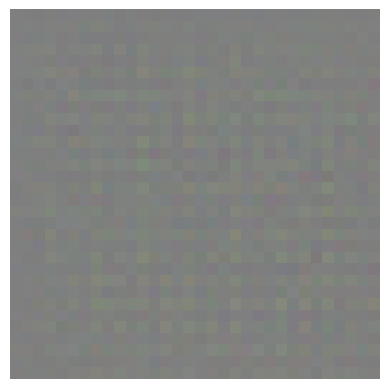

In [3]:
#Generator
def make_generator_model():
    model = tf.keras.Sequential()

    # Start from 8x8 instead of 7x7
    model.add(layers.Dense(8*8*256, use_bias=False, input_shape=(100,)))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Reshape((8, 8, 256)))
    assert model.output_shape == (None, 8, 8, 256)

    # 8x8 → 16x16
    model.add(layers.Conv2DTranspose(128, (5, 5), strides=(2, 2),
                                     padding='same', use_bias=False))
    assert model.output_shape == (None, 16, 16, 128)
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    # 16x16 → 32x32
    model.add(layers.Conv2DTranspose(64, (5, 5), strides=(2, 2),
                                     padding='same', use_bias=False))
    assert model.output_shape == (None, 32, 32, 64)
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    # FINAL LAYER → RGB (3 channels)
    model.add(layers.Conv2DTranspose(3, (5, 5), strides=(1, 1),
                                     padding='same', use_bias=False,
                                     activation='tanh'))
    assert model.output_shape == (None, 32, 32, 3)

    return model

  #Create an image
generator = make_generator_model()

noise = tf.random.normal([1, 100])
generated_image = generator(noise, training=False)

img = (generated_image[0] * 127.5 + 127.5).numpy().astype("uint8")
plt.imshow(img)
plt.axis('off')


In [4]:
#Discriminator
def make_discriminator_model():
    model = tf.keras.Sequential()
    model.add(layers.Conv2D(64, (5, 5), strides=(2, 2), padding='same',
                                     input_shape=[32, 32, 3]))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(128, (5, 5), strides=(2, 2), padding='same'))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Flatten())
    model.add(layers.Dense(1))

    return model

discriminator = make_discriminator_model()
decision = discriminator(generated_image)
print (decision)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


tf.Tensor([[-0.00693907]], shape=(1, 1), dtype=float32)


In [5]:
#Define loss and optimizers
# This method returns a helper function to compute cross entropy loss
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

In [6]:
#Discriminator Loss
def discriminator_loss(real_output, fake_output):
  real_loss = cross_entropy(tf.ones_like(real_output), real_output)
  fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
  total_loss = real_loss + fake_loss
  return total_loss

In [7]:
#Generator Loss
def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

In [8]:
generator_optimizer = tf.keras.optimizers.Adam(1e-4)
discriminator_optimizer = tf.keras.optimizers.Adam(1e-4)

In [9]:
#Save Checkpoints
import os
checkpoint_dir = './training_checkpoints'
checkpoint_prefix = os.path.join(checkpoint_dir, "ckpt")
checkpoint = tf.train.Checkpoint(generator_optimizer=generator_optimizer,
                                 discriminator_optimizer=discriminator_optimizer,
                                 generator=generator,
                                 discriminator=discriminator)

In [10]:
#Define Training Loop
EPOCHS = 30
noise_dim = 100
num_examples_to_generate = 16

# You will reuse this seed overtime (so it's easier)
# to visualize progress in the animated GIF)
seed = tf.random.normal([num_examples_to_generate, noise_dim])
# Notice the use of `tf.function`
# This annotation causes the function to be "compiled".
@tf.function
def train_step(images):
    noise = tf.random.normal([tf.shape(images)[0], noise_dim])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
      generated_images = generator(noise, training=True)

      real_output = discriminator(images, training=True)
      fake_output = discriminator(generated_images, training=True)

      gen_loss = generator_loss(fake_output)
      disc_loss = discriminator_loss(real_output, fake_output)

    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

In [11]:
def train(dataset, epochs):
  for epoch in range(epochs):
    start = time.time()

    for image_batch in dataset:
      train_step(image_batch)

    # Produce images for the GIF as you go
    #display.clear_output(wait=True)
    generate_and_save_images(generator,
                             epoch + 1,
                             seed)

    # Save the model every 15 epochs
    if (epoch + 1) % 15 == 0:
      checkpoint.save(file_prefix = checkpoint_prefix)

    print ('Time for epoch {} is {} sec'.format(epoch + 1, time.time()-start))

  # Generate after the final epoch
  display.clear_output(wait=True)
  generate_and_save_images(generator,
                           epochs,
                           seed)

In [12]:
#Generate and Save Images
def generate_and_save_images(model, epoch, test_input):
  # Notice `training` is set to False.
  # This is so all layers run in inference mode (batchnorm).
  predictions = model(test_input, training=False)

  fig = plt.figure(figsize=(4, 4))

  for i in range(predictions.shape[0]):
      plt.subplot(4, 4, i+1)
      plt.imshow(predictions[i, :, :, 0] * 127.5 + 127.5, cmap='gray')
      plt.axis('off')

  plt.savefig('image_at_epoch_{:04d}.png'.format(epoch))
  plt.show()

In [13]:
#Print check
print(train_dataset)
print(EPOCHS)
import tensorflow as tf
tf.config.list_physical_devices('GPU')

<_BatchDataset element_spec=TensorSpec(shape=(None, 32, 32, 3), dtype=tf.float32, name=None)>
30


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

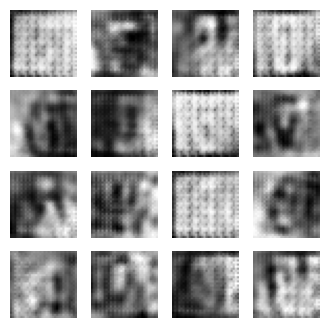

In [14]:
#Train model
print("Starting the training process")
train(train_dataset, EPOCHS)

In [15]:
#Restore last data checkpoints
checkpoint.restore(tf.train.latest_checkpoint(checkpoint_dir))

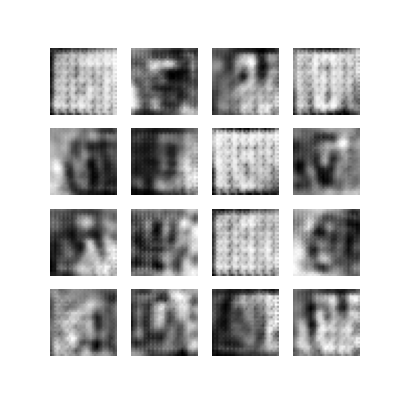

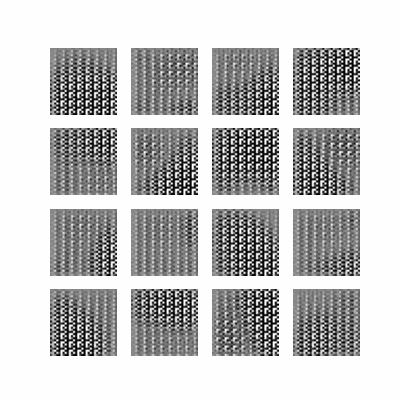

In [19]:
import glob
import imageio
from PIL import Image
from IPython.display import Image as IPImage, display

# Display a single image
def display_image(epoch_no):
    return Image.open(f'image_at_epoch_{epoch_no:04d}.png')

display(display_image(EPOCHS))

# Create GIF
anim_file = 'dcgan.gif'

filenames = glob.glob('image_at_epoch_*.png')
filenames = sorted(filenames)

with imageio.get_writer(anim_file, mode='I') as writer:
    for filename in filenames:
        image = imageio.v2.imread(filename)
        writer.append_data(image)

# Display GIF
display(IPImage(filename=anim_file))